Hello Iris Project

In [7]:
print("Hello Iris Project")

Hello Iris Project


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("iris.csv")
df.head()

In [11]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


Understand the Dataset

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [15]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
df.shape

(150, 5)

In [21]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [26]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [29]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Advanced Pandas Analysis

In [88]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [93]:
df.groupby(df["species"]).mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [95]:
species_summary=df.groupby("species").agg({
    "sepal_length":["max","min","mean"],
    "sepal_width":["max","min","mean"],
    "petal_length":["max","min","mean"],
    "petal_width":["max","min","mean"]
    
})
species_summary

sepal_length             sepal_width             petal_length       \
                    max  min   mean         max  min   mean          max  min   
species                                                                         
setosa              5.8  4.3  5.006         4.4  2.3  3.418          1.9  1.0   
versicolor          7.0  4.9  5.936         3.4  2.0  2.770          5.1  3.0   
virginica           7.9  4.9  6.588         3.8  2.2  2.974          6.9  4.5   

                  petal_width              
             mean         max  min   mean  
species                                    
setosa      1.464         0.6  0.1  0.244  
versicolor  4.260         1.8  1.0  1.326  
virginica   5.552         2.5  1.4  2.026

In [97]:
df["sepal_area"]=df["sepal_length"]*df["sepal_width"]
df["petal_area"]=df["petal_length"]*df["petal_width"]

df

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area
0,5.1,3.5,1.4,0.2,setosa,17.85,0.28
1,4.9,3.0,1.4,0.2,setosa,14.70,0.28
2,4.7,3.2,1.3,0.2,setosa,15.04,0.26
3,4.6,3.1,1.5,0.2,setosa,14.26,0.30
4,5.0,3.6,1.4,0.2,setosa,18.00,0.28
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,20.10,11.96
146,6.3,2.5,5.0,1.9,virginica,15.75,9.50
147,6.5,3.0,5.2,2.0,virginica,19.50,10.40
148,6.2,3.4,5.4,2.3,virginica,21.08,12.42


In [98]:
df.groupby("species")[["sepal_area","petal_area"]].mean()

,sepal_area,petal_area
species,,
setosa,17.2088,0.3628
versicolor,16.5262,5.7204
virginica,19.6846,11.2962


In [103]:
large_petal_flowers=df[df["petal_area"]>df["petal_area"].mean()]

large_petal_flowers["species"].value_counts()

species
virginica     50
versicolor    23
Name: count, dtype: int64

In [104]:
large_petal_flowers

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area
50,7.0,3.2,4.7,1.4,versicolor,22.40,6.58
51,6.4,3.2,4.5,1.5,versicolor,20.48,6.75
52,6.9,3.1,4.9,1.5,versicolor,21.39,7.35
54,6.5,2.8,4.6,1.5,versicolor,18.20,6.90
55,5.7,2.8,4.5,1.3,versicolor,15.96,5.85
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,20.10,11.96
146,6.3,2.5,5.0,1.9,virginica,15.75,9.50
147,6.5,3.0,5.2,2.0,virginica,19.50,10.40
148,6.2,3.4,5.4,2.3,virginica,21.08,12.42


In [107]:
df.sort_values("petal_area",ascending=True,inplace=True)
df

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area
13,4.3,3.0,1.1,0.1,setosa,12.90,0.11
12,4.8,3.0,1.4,0.1,setosa,14.40,0.14
37,4.9,3.1,1.5,0.1,setosa,15.19,0.15
9,4.9,3.1,1.5,0.1,setosa,15.19,0.15
32,5.2,4.1,1.5,0.1,setosa,21.32,0.15
...,...,...,...,...,...,...,...
144,6.7,3.3,5.7,2.5,virginica,22.11,14.25
117,7.7,3.8,6.7,2.2,virginica,29.26,14.74
100,6.3,3.3,6.0,2.5,virginica,20.79,15.00
109,7.2,3.6,6.1,2.5,virginica,25.92,15.25


Correlation

In [108]:
numeric_df = df.select_dtypes(include="number")
numeric_df.corr()

,sepal_length,sepal_width,petal_length,petal_width,sepal_area,petal_area
sepal_length,1.000000,-0.109369,0.871754,0.817954,0.683362,0.857326
sepal_width,-0.109369,1.000000,-0.420516,-0.356544,0.645421,-0.280612
petal_length,0.871754,-0.420516,1.000000,0.962757,0.366584,0.958472
petal_width,0.817954,-0.356544,0.962757,1.000000,0.375365,0.980229
sepal_area,0.683362,0.645421,0.366584,0.375365,1.000000,0.459484
petal_area,0.857326,-0.280612,0.958472,0.980229,0.459484,1.000000


In [112]:
pivot_table=df.pivot_table(
    values=["sepal_length","sepal_width","petal_length","petal_width","sepal_area","petal_area"],
    index="species",
    aggfunc=["mean","std"]   
)
pivot_table

mean                                                   \
           petal_area petal_length petal_width sepal_area sepal_length   
species                                                                  
setosa         0.3628        1.464       0.244    17.2088        5.006   
versicolor     5.7204        4.260       1.326    16.5262        5.936   
virginica     11.2962        5.552       2.026    19.6846        6.588   

                              std                                      \
           sepal_width petal_area petal_length petal_width sepal_area   
species                                                                 
setosa           3.418   0.183248     0.173511    0.107210   2.947688   
versicolor       2.770   1.368403     0.469911    0.197753   2.866882   
virginica        2.974   2.157412     0.551895    0.274650   3.458783   

                                     
           sepal_length sepal_width  
species                              
setosa         0.352490    0.381024  
versicolor     0.516171    0.313798  
virginica      0.635880    0.322497

NumPy Practice

In [32]:
petal_length_values=df["petal_length"].values
petal_length_values

array([1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4,
       1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1. , 1.7, 1.9, 1.6,
       1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.5, 1.3,
       1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5,
       4.9, 4. , 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4. , 4.7, 3.6,
       4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4. , 4.9, 4.7, 4.3, 4.4, 4.8, 5. ,
       4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4. , 4.4,
       4.6, 4. , 3.3, 4.2, 4.2, 4.2, 4.3, 3. , 4.1, 6. , 5.1, 5.9, 5.6,
       5.8, 6.6, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5. , 5.1, 5.3, 5.5,
       6.7, 6.9, 5. , 5.7, 4.9, 6.7, 4.9, 5.7, 6. , 4.8, 4.9, 5.6, 5.8,
       6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1,
       5.9, 5.7, 5.2, 5. , 5.2, 5.4, 5.1])

In [34]:
np.max(petal_length_values)

np.float64(6.9)

In [35]:
np.min(petal_length_values)

np.float64(1.0)

In [36]:
np.mean(petal_length_values)

np.float64(3.758666666666666)

Advanced NumPy Analysis

In [114]:
numeric_data=df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].values
numeric_data.shape

(150, 4)

In [117]:
numeric_data[:5]

array([[4.3, 3. , 1.1, 0.1],
       [4.8, 3. , 1.4, 0.1],
       [4.9, 3.1, 1.5, 0.1],
       [4.9, 3.1, 1.5, 0.1],
       [5.2, 4.1, 1.5, 0.1]])

In [118]:
numeric_data[0,:].mean()

np.float64(2.125)

In [120]:
np.mean(numeric_data,axis=0)

array([5.84333333, 3.054     , 3.75866667, 1.19866667])

In [122]:
col=["sepal_length", "sepal_width", "petal_length", "petal_width"]
means=np.mean(numeric_data,axis=0)
for c,m in zip(col, means):
    print(c,"mean : ",m)

sepal_length mean :  5.843333333333334
sepal_width mean :  3.0540000000000003
petal_length mean :  3.758666666666666
petal_width mean :  1.1986666666666668


In [127]:
col=["sepal_length", "sepal_width", "petal_length", "petal_width"]
mins=np.min(numeric_data,axis=0)
maxs=np.max(numeric_data,axis=0)
std=np.std(numeric_data, axis=0)
for c, min_val, max_val, std_val in zip(col, mins, maxs, std):
    print(c)
    print("min:", min_val)
    print("max:", max_val)
    print("std:", std_val)
    print("-----")


sepal_length
min: 4.3
max: 7.9
std: 0.8253012917851409
-----
sepal_width
min: 2.0
max: 4.4
std: 0.43214658007054346
-----
petal_length
min: 1.0
max: 6.9
std: 1.7585291834055212
-----
petal_width
min: 0.1
max: 2.5
std: 0.7606126185881716
-----


In [132]:
normalized_data = (numeric_data - mins) / (maxs - mins)
normalized_data[:5]

array([[0.        , 0.41666667, 0.01694915, 0.        ],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.25      , 0.875     , 0.08474576, 0.        ]])

In [133]:
np.min(normalized_data, axis=0)

array([0., 0., 0., 0.])

In [134]:
np.max(normalized_data,axis=0)

array([1., 1., 1., 1.])

In [136]:
standardized_data = (numeric_data - means) / std

standardized_data[:5]

array([[-1.87002413, -0.1249576 , -1.51186952, -1.4444497 ],
       [-1.26418478, -0.1249576 , -1.3412724 , -1.4444497 ],
       [-1.14301691,  0.10644536, -1.2844067 , -1.4444497 ],
       [-1.14301691,  0.10644536, -1.2844067 , -1.4444497 ],
       [-0.7795133 ,  2.42047502, -1.2844067 , -1.4444497 ]])

Visualizations

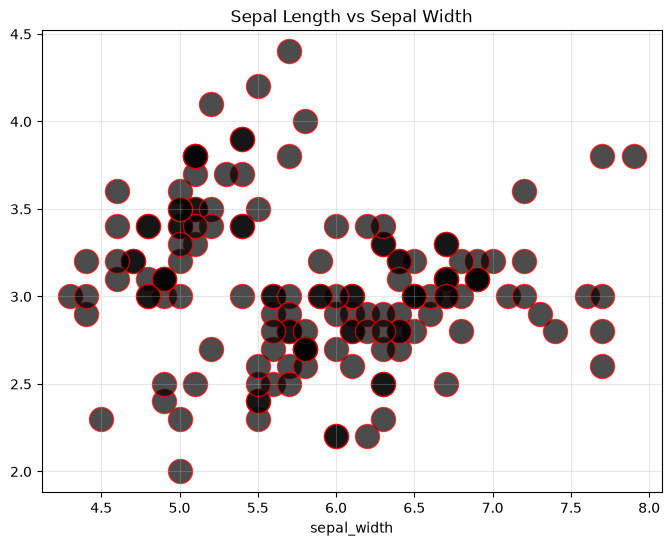

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(df["sepal_length"],df["sepal_width"],color="black",edgecolor="red",s=300,alpha=0.7,marker="o")
plt.xlabel("sepal_length")
plt.xlabel("sepal_width")
plt.title("Sepal Length vs Sepal Width")
plt.grid(True,alpha=0.3)
plt.show()

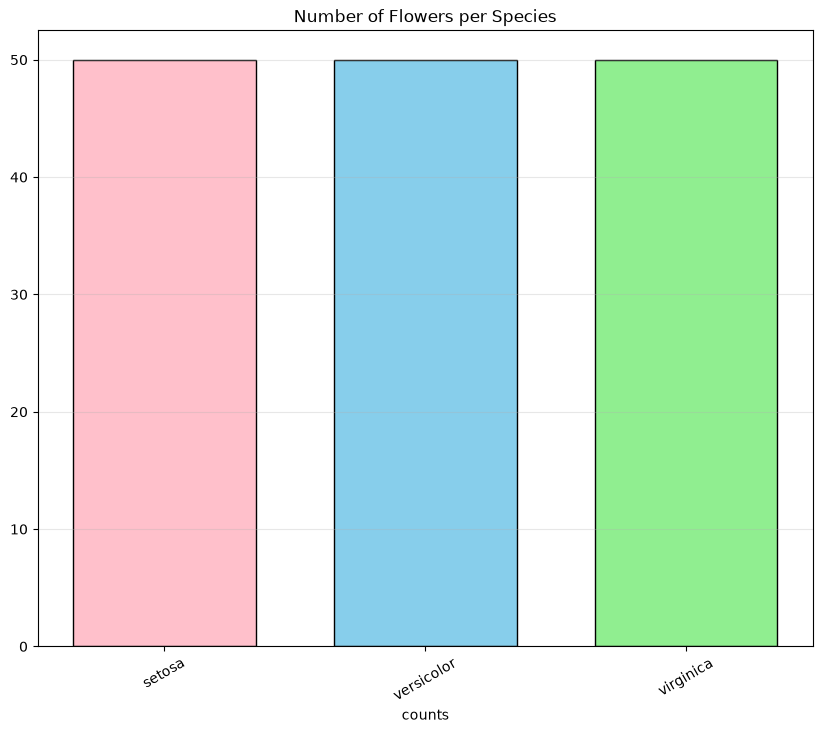

In [71]:
species_count=df["species"].value_counts()
plt.figure(figsize=(10,8))
plt.bar(species_count.index,species_count.values,color=["pink", "skyblue", "lightgreen"],edgecolor="black",width=0.7,alpha=1)
plt.xlabel("species")
plt.xlabel("counts")
plt.title("Number of Flowers per Species")
plt.grid(True,axis="y",alpha=0.3)
plt.xticks(rotation=30)
plt.show()

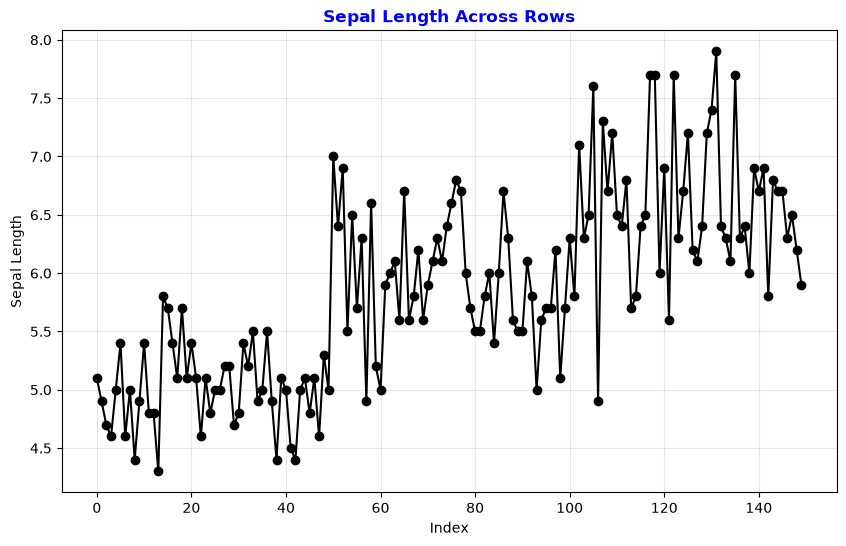

In [85]:
plt.figure(figsize=(10,6))
plt.plot(df["sepal_length"],linestyle="-",marker="o",color="black")
plt.grid(True,alpha=0.3)
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.title("Sepal Length Across Rows",weight="bold",color="blue")
plt.show()

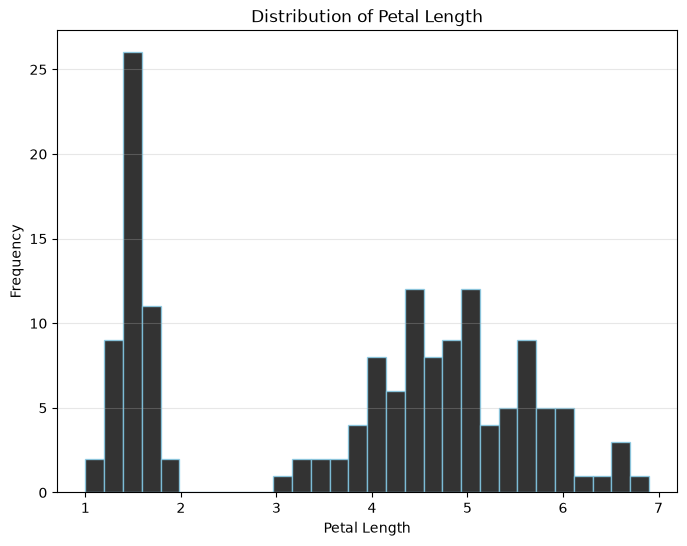

In [87]:
plt.figure(figsize=(8, 6))
plt.hist(df["petal_length"],bins=30,color="black",
         edgecolor="skyblue",alpha=0.8)
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.title("Distribution of Petal Length")
plt.grid(axis="y", alpha=0.3)

plt.show()

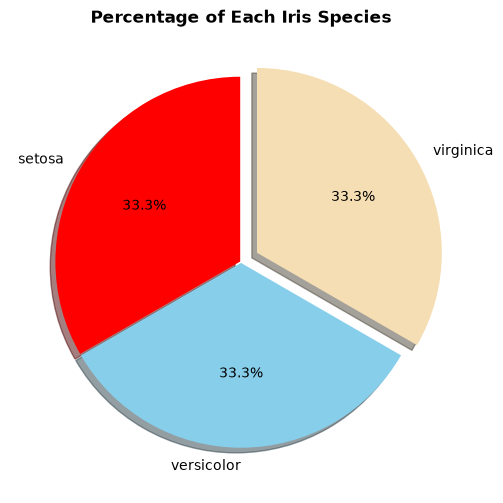

In [157]:
species_counts = df["species"].value_counts()

colors = ["red", "skyblue", "wheat"]
explode = [0.005, 0.005, 0.1]

plt.figure(figsize=(8, 6))

plt.pie(
    species_counts.values,
    labels=species_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True
)

plt.title("Percentage of Each Iris Species", fontweight="bold")
plt.show()
